# Max-Cut (10,000 Vertices) on Dynex n.quantum computing cloud

In [1]:
import dimod
import networkx as nx

from collections import defaultdict

from dynex import DynexConfig, ComputeBackend, DynexSampler, BQM, QPUModel

config = DynexConfig(compute_backend=ComputeBackend.CPU, qpu_model=QPUModel.APOLLO_RC1, use_notebook_output=True)

## Simple Max-Cut graph

In [2]:
# Create empty graph
G = nx.Graph()

In [3]:
# Add edges to the graph (also adds nodes)
G.add_edges_from([(1,2),(1,3),(2,4),(3,4),(3,5),(4,5)])

In [4]:
# ------- Set up our QUBO dictionary -------

# Initialize our Q matrix
Q = defaultdict(int)

# Update Q matrix for every edge in the graph
for i, j in G.edges:
    Q[(i,i)]+= -1
    Q[(j,j)]+= -1
    Q[(i,j)]+= 2

In [5]:
# Sample on Dynex
bqm = dimod.BinaryQuadraticModel.from_qubo(Q, 0.0)
model = BQM(bqm, logging=False, formula=2, config=config)
sampler = DynexSampler(model, logging=False, description="Dynex SDK job", bnb=True, config=config)

sampleset = sampler.sample(num_reads=10, annealing_time=100)
print('Result:')
print(sampleset)

Result:
   1  2  3  4  5 energy num_oc.
0  1  0  0  1  0   -5.0       1
['BINARY', 1 rows, 1 samples, 5 variables]


Maxcut result: 5


{1: Text(0.7243532747757099, 0.4339629874185834, '1'),
 2: Text(0.7298889722132111, -0.42487458162911096, '2'),
 3: Text(-0.22969347550389815, 0.40015808123578755, '3'),
 4: Text(-0.22454877148502297, -0.40293977352734855, '4'),
 5: Text(-1.0, -0.006306713497911264, '5')}

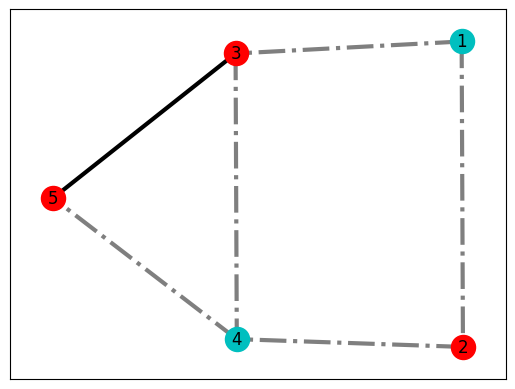

In [6]:
# Grab best result
lut = sampleset.first.sample

# Interpret best result in terms of nodes and edges
S0 = [node for node in G.nodes if not lut[node]]
S1 = [node for node in G.nodes if lut[node]]
cut_edges = [(u, v) for u, v in G.edges if lut[u]!=lut[v]]
uncut_edges = [(u, v) for u, v in G.edges if lut[u]==lut[v]]

print('Maxcut result:',len(cut_edges))

# Display best result
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos, nodelist=S0, node_color='r')
nx.draw_networkx_nodes(G, pos, nodelist=S1, node_color='c')
nx.draw_networkx_edges(G, pos, edgelist=cut_edges, style='dashdot', alpha=0.5, width=3)
nx.draw_networkx_edges(G, pos, edgelist=uncut_edges, style='solid', width=3)
nx.draw_networkx_labels(G, pos)

## 10,000 Vertices

In [7]:
import numpy as np

In [8]:
filename = 'G70.dat' 

In [9]:
f = open(filename, "r").readlines()

In [10]:
b_matrix=False
bin_size = f[0].split(" ")[0]
Q = np.zeros([int(bin_size) + 1, int(bin_size) + 1])
init_bin = np.zeros([int(bin_size) + 1])
init_bin[-1] = 1
for ele in f[1:]:
    i, j, v = ele.split()
    if b_matrix == True :
        Q[int(i) - 1, int(j) - 1] += int(v)
        if (int(i) != int(j)):
            Q[int(j) - 1, int(i) - 1] += int(v)
    else :
        if (int(i) == int(j)) :
            print('No edge connected at the same Node',int(i),int(j))
        else :
            Q[int(i), int(j)] += int(v)
            Q[int(j), int(i)] += int(v)
            Q[int(i), int(i)] += -int(v)
            Q[int(j), int(j)] += -int(v)

In [11]:
# Sample on Dynex
bqm = dimod.BinaryQuadraticModel.from_qubo(Q, 0.0)
model = BQM(bqm)
sampler = DynexSampler(model, logging=False, description="Dynex SDK job", bnb=True, config=config)

sampleset = sampler.sample(num_reads=1, annealing_time=10, alpha=0.05, beta=0.2)
print('Result:')
print(sampleset)

Result:
   0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 ... 10000  energy num_oc.
0  1  1  0  1  0  0  1  0  0  0  1  1  1  0  0  0  0 ...     1 -5032.0       1
['BINARY', 1 rows, 1 samples, 10001 variables]
